# Analista de Marketing i Estratégia Comercial: 29/06/2026
Cuál es el precio medio de los alojamientos por tipo de alojamiento en cada ciudad?

In [10]:
# cambiar por el dataset listo

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from pathlib import Path



In [11]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Función para encontrar la carpeta raíz del proyecto subiendo desde el directorio actual.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}")

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_29_06_2026.csv'

print(f"Ruta resuelta: {ruta}")
df_original = pd.read_csv(ruta)
df = df_original.copy()

print(df.shape)

Ruta resuelta: /Users/didi/Desktop/Data_Analisis/simulador_ita/ProjecteData/Equip_34/Data/clean_dataset_29_06_2026.csv
(6733, 35)


### Desglose y preparación de la pregunta-resupuesta
Variables 
- price avg 
- room_type
- city 

Métricas (cálculo) 
- AVG agrupado por tipo y ciudad 

Análisis (tipo de herramienta o elemento estadístico) 
- MEDIA (ir haciendo zoom --> global --> ciudad --> tipo --> tipo y ciudad) 
- Test de diferencia de medias (comparativa puede ser anova o tuckey p ejemplo) 

Respuesta
- El precio medio por tipo de alojamiento y ciudad es X€. 
- Comparar y realizar una frase en diferencias de interés  

In [12]:
df.groupby(['room_type', 'city'])['price_€'].mean().sort_values(ascending=False)

room_type        city     
Entire home/apt  mallorca     1708.954593
                 menorca      1656.532258
Hotel room       barcelona    1444.285714
                 mallorca     1401.666667
Entire home/apt  barcelona    1299.666667
                 girona       1226.203156
                 sevilla      1033.601533
Hotel room       valencia      955.000000
Entire home/apt  madrid        939.428891
Hotel room       sevilla       918.571429
                 madrid        902.500000
Entire home/apt  malaga        815.595668
                 valencia      794.571429
Hotel room       malaga        703.333333
Private room     mallorca      700.253165
Hotel room       girona        625.000000
Private room     menorca       610.000000
                 sevilla       606.000000
                 girona        602.115385
Shared room      mallorca      493.333333
Private room     barcelona     454.713076
                 madrid        373.037975
Shared room      barcelona     371.875000
Private

Precio promedio global

In [13]:
precio_medio_global=df['price_€'].mean().round(2)
print(precio_medio_global)

1009.36


Precio por ciudad

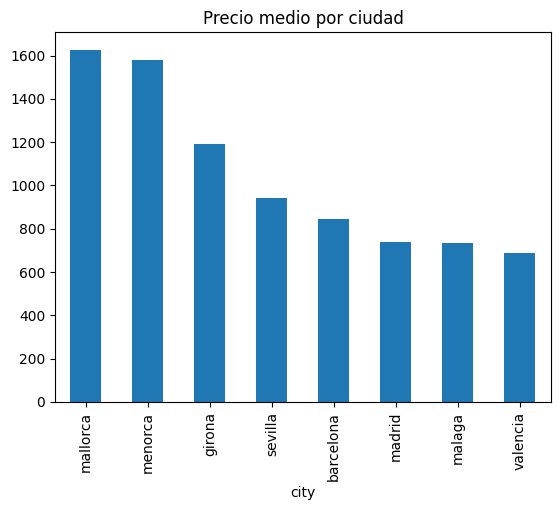

In [14]:
df.groupby('city')['price_€'].mean().sort_values(ascending=False).plot(kind='bar', title='Precio medio por ciudad') ; 

ANOVA entre ciudades

In [15]:
print("=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES ===")

# Pasamos los datos filtrando los nulos solo al momento de ejecutar el test
tukey_ciudades = pairwise_tukeyhsd(
    endog=df['price_€'].dropna(), 
    groups=df.loc[df['price_€'].notna(), 'city'], 
    alpha=0.05
)

# Convertimos a DataFrame de pandas para leerlo fácilmente
df_ciudades = pd.DataFrame(data=tukey_ciudades._results_table.data[1:], 
                           columns=tukey_ciudades._results_table.data[0])

# Mostramos las comparaciones donde SÍ hay diferencias significativas (reject == True)
print("\n--- Comparaciones entre ciudades que resultaron SIGNIFICATIVAS ---")
print(df_ciudades[df_ciudades['reject'] == True].to_string(index=False))

=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES ===

--- Comparaciones entre ciudades que resultaron SIGNIFICATIVAS ---
   group1   group2  meandiff  p-adj      lower     upper  reject
barcelona   girona  346.3494 0.0000   256.7479  435.9509    True
barcelona   madrid -108.4312 0.0018  -191.0911  -25.7713    True
barcelona mallorca  779.3802 0.0000   688.7944  869.9660    True
barcelona  menorca  731.1561 0.0000   519.8188  942.4933    True
barcelona valencia -157.9775 0.0265  -305.8684  -10.0865    True
   girona   madrid -454.7806 0.0000  -551.1846 -358.3765    True
   girona   malaga -459.6617 0.0000  -607.4723 -311.8511    True
   girona mallorca  433.0308 0.0000   329.7503  536.3114    True
   girona  menorca  384.8067 0.0000   167.7249  601.8885    True
   girona  sevilla -253.3902 0.0000  -401.0350 -105.7453    True
   girona valencia -504.3268 0.0000  -660.3166 -348.3371    True
   madrid mallorca  887.8114 0.0000   790.4919  985.1310    True
   madrid  menorca  839.5872 0.000

Precio por tipo de alojamiento

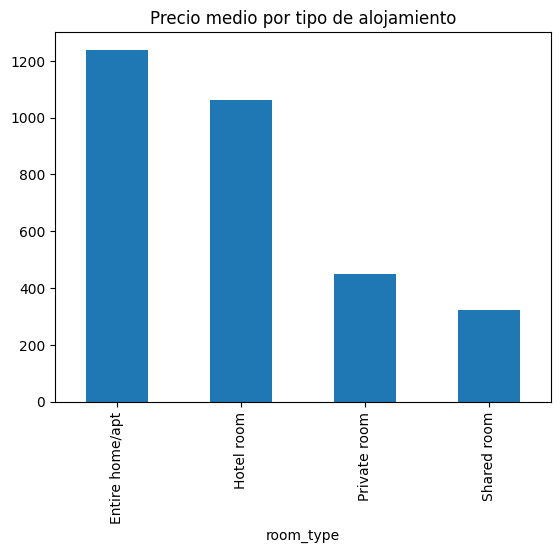

In [16]:
df.groupby('room_type')['price_€'].mean().sort_values(ascending=False).plot(kind='bar', title='Precio medio por tipo de alojamiento') ;

ANOVA entre tipo de alojamiento

In [17]:
print("\n=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO ===")

# Pasamos los datos filtrando los nulos solo al momento de ejecutar el test
tukey_tipos = pairwise_tukeyhsd(
    endog=df['price_€'].dropna(), 
    groups=df.loc[df['price_€'].notna(), 'room_type'], 
    alpha=0.05
)

# Convertimos a DataFrame de pandas
df_tipos = pd.DataFrame(data=tukey_tipos._results_table.data[1:], 
                        columns=tukey_tipos._results_table.data[0])

# Mostramos el resultado completo (al ser solo 4 tipos, la tabla es pequeña y fácil de leer)
print("\n--- Resultado de todas las comparaciones de alojamiento ---")
print(df_tipos.to_string(index=False))


=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO ===

--- Resultado de todas las comparaciones de alojamiento ---
         group1       group2  meandiff  p-adj      lower     upper  reject
Entire home/apt   Hotel room -176.4631 0.5494  -519.6713  166.7452   False
Entire home/apt Private room -791.3670 0.0000  -845.1520 -737.5820    True
Entire home/apt  Shared room -915.3470 0.0000 -1223.5180 -607.1760    True
     Hotel room Private room -614.9040 0.0000  -959.9136 -269.8943    True
     Hotel room  Shared room -738.8840 0.0002 -1198.3491 -279.4188    True
   Private room  Shared room -123.9800 0.7335  -434.1560  186.1960   False


Crear la tabla agrupada (MultiIndex)

In [18]:

tabla_opcion1 = (
    df.groupby(["city", "room_type"])["price_€"]
    .mean()
    .sort_values(ascending=False)
)


 2. Graficar agrupando visualmente por el primer nivel (city)
.unstack() pasa 'room_type' a las columnas, creando el agrupamiento ideal para el gráfico

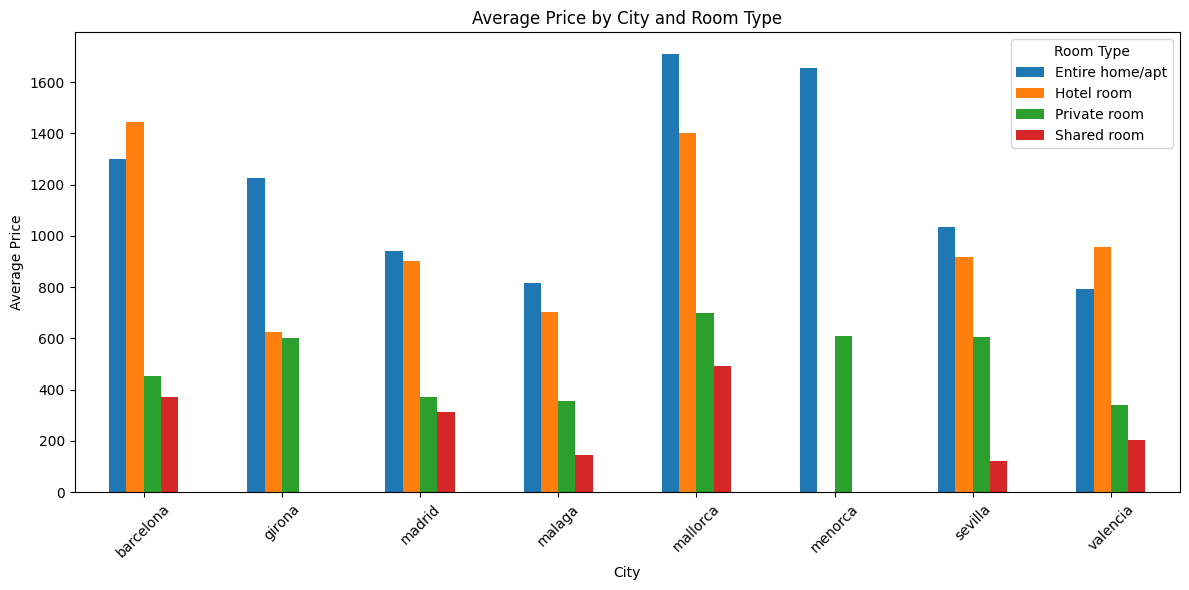

In [19]:
tabla_opcion1.unstack().plot(kind="bar", figsize=(12, 6))

plt.title("Average Price by City and Room Type")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

POST- HOC Comparativa de alojamientos entre tipos en la misma ciudad

In [20]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== PARTE 1: ALOJAMIENTOS DENTRO DE LA MISMA CIUDAD ===")

# Recorremos cada ciudad con pandas
for ciudad, sub_df in df.groupby('city'):
    print(f"\n--- Resultados para: {ciudad} ---")
    
    # Hacemos el test de Tukey solo con los datos de esta ciudad
    tukey = pairwise_tukeyhsd(endog=sub_df['price_€'], 
                              groups=sub_df['room_type'], 
                              alpha=0.05)
    
    # Lo convertimos a DataFrame de pandas para que se vea limpio
    print(pd.DataFrame(data=tukey._results_table.data[1:], 
                       columns=tukey._results_table.data[0]))
    print("\n")

=== PARTE 1: ALOJAMIENTOS DENTRO DE LA MISMA CIUDAD ===

--- Resultados para: barcelona ---
            group1        group2  meandiff  p-adj  lower  upper  reject
0  Entire home/apt    Hotel room       NaN    NaN    NaN    NaN   False
1  Entire home/apt  Private room       NaN    NaN    NaN    NaN   False
2  Entire home/apt   Shared room       NaN    NaN    NaN    NaN   False
3       Hotel room  Private room       NaN    NaN    NaN    NaN   False
4       Hotel room   Shared room       NaN    NaN    NaN    NaN   False
5     Private room   Shared room       NaN    NaN    NaN    NaN   False



--- Resultados para: girona ---
            group1        group2  meandiff  p-adj  lower  upper  reject
0  Entire home/apt    Hotel room       NaN    NaN    NaN    NaN   False
1  Entire home/apt  Private room       NaN    NaN    NaN    NaN   False
2       Hotel room  Private room  -22.8846    NaN    NaN    NaN   False



--- Resultados para: madrid ---
            group1        group2  meandiff  p-

POST- HOC Comparativa de tipos de alojamientos entre ciudades

In [21]:
print("\n=== PARTE 2: MISMO ALOJAMIENTO ENTRE DIFERENTES CIUDADES ===")

# Recorremos cada tipo de alojamiento con pandas
for alojamiento, sub_df in df.groupby('room_type'):
    print(f"\n--- Resultados para el alojamiento: {alojamiento} ---")
    
    # Hacemos el test de Tukey comparando las ciudades para este alojamiento
    tukey = pairwise_tukeyhsd(endog=sub_df['price_€'], 
                              groups=sub_df['city'], 
                              alpha=0.05)
    
    # Lo convertimos a DataFrame de pandas
    print(pd.DataFrame(data=tukey._results_table.data[1:], 
                       columns=tukey._results_table.data[0]))


=== PARTE 2: MISMO ALOJAMIENTO ENTRE DIFERENTES CIUDADES ===

--- Resultados para el alojamiento: Entire home/apt ---
       group1    group2  meandiff  p-adj  lower  upper  reject
0   barcelona    girona       NaN    NaN    NaN    NaN   False
1   barcelona    madrid       NaN    NaN    NaN    NaN   False
2   barcelona    malaga       NaN    NaN    NaN    NaN   False
3   barcelona  mallorca       NaN    NaN    NaN    NaN   False
4   barcelona   menorca       NaN    NaN    NaN    NaN   False
5   barcelona   sevilla       NaN    NaN    NaN    NaN   False
6   barcelona  valencia       NaN    NaN    NaN    NaN   False
7      girona    madrid       NaN    NaN    NaN    NaN   False
8      girona    malaga       NaN    NaN    NaN    NaN   False
9      girona  mallorca       NaN    NaN    NaN    NaN   False
10     girona   menorca       NaN    NaN    NaN    NaN   False
11     girona   sevilla       NaN    NaN    NaN    NaN   False
12     girona  valencia       NaN    NaN    NaN    NaN   False